# 🚍 GTFS Diagnostics — Operational Intelligence Report

> A comprehensive diagnostic analysis of a GTFS transit feed,
> extracting operational metrics, spatial patterns, and service quality
> indicators from schedule data.

### Contents

| # | Section | Key outputs |
|---|---|---|
| 1 | **Setup & Feed Overview** | Table counts, date range, agency info |
| 2 | **Service Profile** | Active trips over the day (10-min bins) |
| 3 | **Stop-level Analysis** | Headway & frequency maps, busiest stops |
| 4 | **Route Corridors** | Segment-level route concentration |
| 5 | **Service Kilometres** | Daily VKT, distance by route and time window |
| 6 | **Trip Summary Table** | Trips × time window, km/trip, total km |
| 7 | **Diagnostics** | Speed anomalies, stop spacing, trip duration outliers |

---
## 0 — Configuration

In [66]:
# ── Point this to your GTFS feed ─────────────────────────────────────
GTFS_PATH = "../data/processed/20260325_183744/gtfs.zip"

# Analysis date (None = auto-detect busiest date)
ANALYSIS_DATE: str | None = None

# Time windows for summary tables (hours)
TIME_WINDOWS = [
    ("Madrugada",  "00:00:00", "05:00:00"),
    ("Manhã Pico", "05:00:00", "09:00:00"),
    ("Entrepico",  "09:00:00", "16:00:00"),
    ("Tarde Pico",  "16:00:00", "20:00:00"),
    ("Noite",       "20:00:00", "24:00:00"),
]

# Headway computation window
HEADWAY_START = "06:00:00"
HEADWAY_END   = "22:00:00"

# CRS for distance calculations (UTM zone for your city)
# Set to None for auto-detection
LOCAL_CRS: int | None = None

---
## 1 — Setup & Feed Overview

In [67]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import geopandas as gpd
import gtfs_kit as gk
import json
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import shapely.geometry as sg
from IPython.display import display, HTML

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", "{:.1f}".format)

# ── Plotting defaults ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# ── Color palette ────────────────────────────────────────────────────
PAL = {
    "primary": "#2196F3",
    "secondary": "#FF5722",
    "accent": "#4CAF50",
    "dark": "#263238",
    "light": "#ECEFF1",
    "ida": "#2196F3",
    "volta": "#FF5722",
}
WINDOW_COLORS = ["#455A64", "#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]

In [68]:
# ── Read feed ────────────────────────────────────────────────────────
feed = gk.read_feed(GTFS_PATH, dist_units="km")

# Append shape_dist_traveled if missing
if feed.stop_times is not None and "shape_dist_traveled" not in feed.stop_times.columns:
    feed = feed.append_dist_to_stop_times()

print(f"Feed: {GTFS_PATH}")


Feed: ../data/processed/20260325_183744/gtfs.zip


In [69]:
# ── Detect analysis date ─────────────────────────────────────────────
if ANALYSIS_DATE is None:
    # Find the date with the most trips
    dates = feed.get_dates()
    trip_counts = {
        d: feed.compute_trip_activity([d])[d].sum() for d in dates[:30]
    }
    ANALYSIS_DATE = max(trip_counts, key=trip_counts.get)

print(f"Analysis date: {ANALYSIS_DATE} (busiest)")

# Auto-detect CRS
if LOCAL_CRS is None:
    shapes_gdf = gk.geometrize_shapes(feed.shapes)
    LOCAL_CRS = shapes_gdf.estimate_utm_crs().to_epsg()
print(f"Local CRS: EPSG:{LOCAL_CRS}")

Analysis date: 20260101 (busiest)
Local CRS: EPSG:32723


In [70]:
# ── Feed overview card ───────────────────────────────────────────────
agency = feed.agency.iloc[0] if feed.agency is not None else {}

overview = {
    "Operadora": agency.get("agency_name", "—"),
    "Timezone": agency.get("agency_timezone", "—"),
    "Rotas": len(feed.routes) if feed.routes is not None else 0,
    "Paradas": len(feed.stops) if feed.stops is not None else 0,
    "Viagens (total)": len(feed.trips) if feed.trips is not None else 0,
    "Shapes": feed.shapes["shape_id"].nunique() if feed.shapes is not None else 0,
    "Datas no feed": len(feed.get_dates()),
}

overview_df = pd.DataFrame(
    list(overview.items()), columns=["Métrica", "Valor"]
)
display(
    overview_df.style
    .set_properties(**{"font-weight": "bold"}, subset=["Métrica"])
    .hide(axis="index")
    .set_caption("Feed Overview")
)

Métrica,Valor
Operadora,Salineira
Timezone,America/Sao_Paulo
Rotas,23
Paradas,830
Viagens (total),1722
Shapes,46
Datas no feed,365


In [71]:
# ── Compute route time series (20-min bins) ──────────────────────────
rts = feed.compute_route_time_series(
    [ANALYSIS_DATE], freq="20min", split_directions=False,
)

# Aggregate across all routes → network-level time series
nts = (
    rts.groupby("datetime")
    .agg(
        num_trips=("num_trips", "sum"),
        num_trip_starts=("num_trip_starts", "sum"),
        service_distance=("service_distance", "sum"),
        service_duration=("service_duration", "sum"),
    )
    .reset_index()
)
nts["hour"] = pd.to_datetime(nts["datetime"]).dt.hour + pd.to_datetime(nts["datetime"]).dt.minute / 60

print(f"Time series: {len(nts)} bins, {nts['num_trips'].max():.0f} peak simultaneous trips")

Time series: 72 bins, 59 peak simultaneous trips


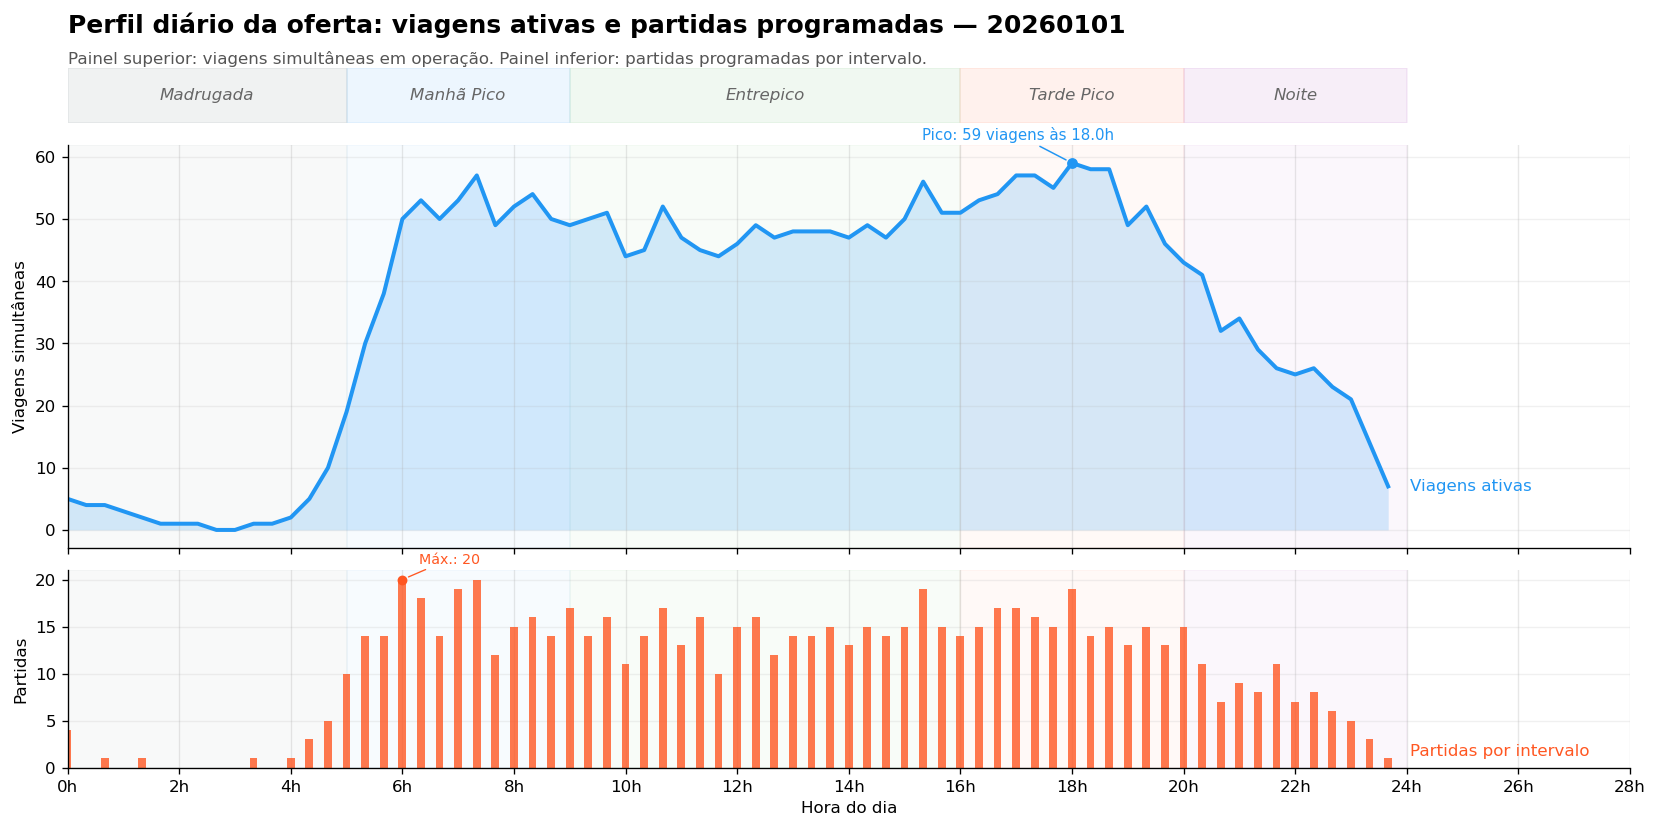

In [74]:
# ── Service profile plot (editorial layout, no overlap) ──────────────
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

peak_active_idx = nts["num_trips"].idxmax()
peak_start_idx = nts["num_trip_starts"].idxmax()

peak_active_hour = nts.loc[peak_active_idx, "hour"]
peak_active_val = nts.loc[peak_active_idx, "num_trips"]

peak_start_hour = nts.loc[peak_start_idx, "hour"]
peak_start_val = nts.loc[peak_start_idx, "num_trip_starts"]

fig = plt.figure(figsize=(14, 7.2))
gs = GridSpec(
    nrows=3,
    ncols=1,
    height_ratios=[0.32, 2.35, 1.15],
    hspace=0.10,
    figure=fig,
)

ax_band = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax_band)
ax2 = fig.add_subplot(gs[2], sharex=ax_band)

# generous figure margins to separate title block from content
fig.subplots_adjust(left=0.06, right=0.99, bottom=0.09, top=0.90)

# ── title block at figure level
fig.text(
    0.06, 0.965,
    f"Perfil diário da oferta: viagens ativas e partidas programadas — {ANALYSIS_DATE}",
    ha="left", va="top",
    fontsize=15, fontweight="bold",
)
fig.text(
    0.06, 0.92,
    "Painel superior: viagens simultâneas em operação. Painel inferior: partidas programadas por intervalo.",
    ha="left", va="top",
    fontsize=10, color="#555555",
)

# ── dedicated band for time windows
ax_band.set_xlim(0, 28)
ax_band.set_ylim(0, 1)

for i, (name, t0, t1) in enumerate(TIME_WINDOWS):
    h0 = int(t0.split(":")[0])
    h1 = int(t1.split(":")[0])

    ax_band.axvspan(h0, h1, ymin=0, ymax=1, alpha=0.08, color=WINDOW_COLORS[i], zorder=1)
    ax1.axvspan(h0, h1, ymin=0, ymax=1, alpha=0.035, color=WINDOW_COLORS[i], zorder=0)
    ax2.axvspan(h0, h1, ymin=0, ymax=1, alpha=0.035, color=WINDOW_COLORS[i], zorder=0)

    ax_band.text(
        (h0 + h1) / 2, 0.5, name,
        ha="center", va="center",
        fontsize=10, color="#666666", fontstyle="italic"
    )

# band cleanup
for spine in ax_band.spines.values():
    spine.set_visible(False)
ax_band.set_yticks([])
ax_band.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax_band.grid(False)

# ── upper panel: active trips
ax1.fill_between(
    nts["hour"], nts["num_trips"],
    color=PAL["primary"], alpha=0.18, linewidth=0, zorder=1
)
ax1.plot(
    nts["hour"], nts["num_trips"],
    color=PAL["primary"], linewidth=2.4, zorder=2
)
ax1.scatter(
    [peak_active_hour], [peak_active_val],
    color=PAL["primary"], s=30, zorder=3
)

# peak annotation deliberately placed down-left to avoid header area
ax1.annotate(
    f"Pico: {peak_active_val:.0f} viagens às {peak_active_hour:.1f}h",
    xy=(peak_active_hour, peak_active_val),
    xytext=(-90, 12),
    textcoords="offset points",
    ha="left", va="bottom",
    fontsize=9, color=PAL["primary"],
    arrowprops=dict(
        arrowstyle="-",
        color=PAL["primary"],
        lw=0.9,
        shrinkA=0, shrinkB=4,
    ),
)

# direct label near the right edge, unclipped
ax1.text(
    24.05,
    nts["num_trips"].iloc[-1],
    "Viagens ativas",
    ha="left", va="center",
    fontsize=10, color=PAL["primary"],
    clip_on=False,
)

ax1.set_ylabel("Viagens simultâneas")

# ── lower panel: trip starts
ax2.bar(
    nts["hour"], nts["num_trip_starts"],
    width=0.14,
    color=PAL["secondary"],
    alpha=0.80,
    edgecolor="none",
    zorder=2,
)
ax2.scatter(
    [peak_start_hour], [peak_start_val],
    color=PAL["secondary"], s=24, zorder=3
)

# place annotation to the right and slightly above, away from panel top edge
ax2.annotate(
    f"Máx.: {peak_start_val:.0f}",
    xy=(peak_start_hour, peak_start_val),
    xytext=(10, 8),
    textcoords="offset points",
    ha="left", va="bottom",
    fontsize=8.5, color=PAL["secondary"],
    arrowprops=dict(
        arrowstyle="-",
        color=PAL["secondary"],
        lw=0.8,
        shrinkA=0, shrinkB=4,
    ),
)

ax2.text(
    24.05,
    nts["num_trip_starts"].iloc[-1],
    "Partidas por intervalo",
    ha="left", va="bottom",
    fontsize=10, color=PAL["secondary"],
    clip_on=False,
)

ax2.set_ylabel("Partidas")
ax2.set_xlabel("Hora do dia")

# ── shared cleanup
for ax in (ax1, ax2):
    ax.set_xlim(0, 28)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.18)

ax1.tick_params(axis="x", labelbottom=False)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.xaxis.set_major_formatter(lambda x, _: f"{int(x)}h")

plt.show()

In [36]:
# ── Peak metrics ─────────────────────────────────────────────────────
peak_idx = nts["num_trips"].idxmax()
peak = nts.loc[peak_idx]

total_service_km = nts["service_distance"].sum() / 1000
total_service_h = nts["service_duration"].sum()
avg_service_speed_kmh = total_service_km / max(1e-9, total_service_h)

metrics = {
    "Pico de viagens simultâneas": f"{peak['num_trips']:.0f}",
    "Horário do pico": f"{peak['hour']:.1f}h",
    "Total de partidas no dia": f"{nts['num_trip_starts'].sum():.0f}",
    "Distância total (km)": f"{total_service_km:,.0f}",
    "Duração total (h)": f"{total_service_h:,.0f}",
    "Vel. média (km/h)": f"{avg_service_speed_kmh:.1f}",
}

display(
    pd.DataFrame(list(metrics.items()), columns=["Indicador", "Valor"])
    .style.hide(axis="index").set_caption("Métricas de pico")
)


Indicador,Valor
Pico de viagens simultâneas,53
Horário do pico,18.7h
Total de partidas no dia,781
Distância total (km),"11,788"
Duração total (h),607
Vel. média (km/h),19.4


---
## 3 — Stop-level Analysis

### 3.1 Stop statistics & headway distribution

In [37]:
# ── Compute stop stats ───────────────────────────────────────────────
stop_stats = feed.compute_stop_stats(
    [ANALYSIS_DATE],
    headway_start_time=HEADWAY_START,
    headway_end_time=HEADWAY_END,
    split_directions=False,
)

# Merge geometry
stops_gdf = (
    feed.stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]]
    .merge(stop_stats, on="stop_id", how="inner")
    .pipe(lambda df: gpd.GeoDataFrame(
        df, crs=4326,
        geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),
    ))
)

# Frequency per hour
stops_gdf["frequency_per_hour"] = np.where(
    stops_gdf["mean_headway"] > 0,
    60 / stops_gdf["mean_headway"],
    0,
)

print(f"Stops with stats: {len(stops_gdf)}")
display(
    stops_gdf
    .nlargest(10, "num_trips")
    [["stop_name", "num_trips", "mean_headway", "frequency_per_hour"]]
    .style.format({"mean_headway": "{:.1f}", "frequency_per_hour": "{:.1f}"})
    .set_caption("Top 10 paradas por viagens")
    .hide(axis="index")
)

Stops with stats: 830


stop_name,num_trips,mean_headway,frequency_per_hour
"Avenida Júlia Kubitschek, 20",675.000000,1.6,38.2
Avenida Júlia Kubitsheck 587,634.000000,1.7,35.8
Avenida Júlia Kubitschek 562,624.000000,1.7,35.2
"Av. Júlia Kubitscheck, 125",601.000000,1.8,33.8
"Rua Silva Jardim, 9",601.000000,1.8,33.8
"Avenida Júlia Kubitschek, 26",593.000000,1.8,33.2
"Avenida Teixeira e Souza, 2031",584.000000,1.8,32.7
"Avenida Teixeira e Souza, 1600",584.000000,1.8,32.7
Avenida Teixeira e Souza 202,584.000000,1.8,32.7
Avenida Teixeira e Souza 2,584.000000,1.8,32.7


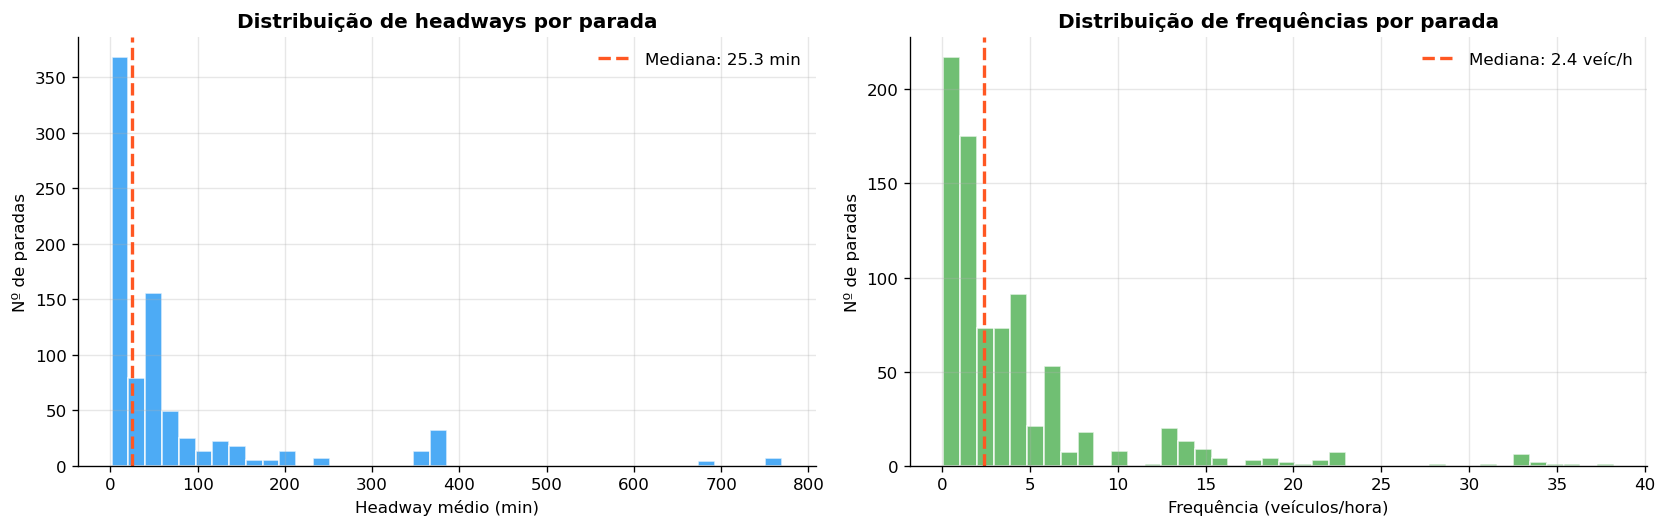

In [38]:
# ── Headway distribution histogram ──────────────────────────────────
hw = stops_gdf["mean_headway"].dropna()
hw = hw[hw > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.hist(hw, bins=40, color=PAL["primary"], edgecolor="white", alpha=0.8)
ax1.axvline(hw.median(), color=PAL["secondary"], linewidth=2, linestyle="--",
            label=f"Mediana: {hw.median():.1f} min")
ax1.set_xlabel("Headway médio (min)")
ax1.set_ylabel("Nº de paradas")
ax1.set_title("Distribuição de headways por parada", fontweight="bold")
ax1.legend(frameon=False)

freq = stops_gdf["frequency_per_hour"].dropna()
freq = freq[freq > 0]
ax2.hist(freq, bins=40, color=PAL["accent"], edgecolor="white", alpha=0.8)
ax2.axvline(freq.median(), color=PAL["secondary"], linewidth=2, linestyle="--",
            label=f"Mediana: {freq.median():.1f} veíc/h")
ax2.set_xlabel("Frequência (veículos/hora)")
ax2.set_ylabel("Nº de paradas")
ax2.set_title("Distribuição de frequências por parada", fontweight="bold")
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

### 3.2 Frequency map

In [39]:
# ── Interactive map: frequency per hour at each stop ─────────────────
gdf = stops_gdf.loc[stops_gdf["frequency_per_hour"] > 0].copy()

fig = px.scatter_mapbox(
    gdf,
    lat="stop_lat", lon="stop_lon",
    size="frequency_per_hour",
    color="frequency_per_hour",
    color_continuous_scale="Plasma_r",
    size_max=14,
    hover_name="stop_name",
    hover_data={
        "num_trips": True,
        "mean_headway": ":.1f",
        "frequency_per_hour": ":.1f",
        "stop_lat": False, "stop_lon": False,
    },
    mapbox_style="carto-positron",
    zoom=11,
    title=f"Frequência por parada ({HEADWAY_START}–{HEADWAY_END})",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_2328\629672563.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### 3.3 Headway map

In [40]:
# ── Headway map (lower = better service) ─────────────────────────────
gdf_hw = stops_gdf.loc[stops_gdf["mean_headway"] > 0].copy()

fig = px.scatter_mapbox(
    gdf_hw,
    lat="stop_lat", lon="stop_lon",
    size="num_trips",
    color="mean_headway",
    color_continuous_scale="RdYlGn_r",
    size_max=12,
    hover_name="stop_name",
    hover_data={
        "num_trips": True,
        "mean_headway": ":.1f",
        "stop_lat": False, "stop_lon": False,
    },
    mapbox_style="carto-positron",
    zoom=11,
    title=f"Headway médio por parada ({HEADWAY_START}–{HEADWAY_END})",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_2328\1031365359.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



---
## 4 — Route Corridors

Segments with the greatest concentration of overlapping routes.
Built by snapping routes to a common network of inter-stop edges and
counting how many route-directions traverse each segment.

In [41]:
# ── Build route corridor concentration ───────────────────────────────
# Mantém duas leituras:
# 1) segmento direcional stop->stop
# 2) corredor agregado, colapsando ida/volta no mesmo par de paradas

st = feed.stop_times.copy()
trips = feed.trips[["trip_id", "route_id", "direction_id"]].copy()
trips["direction_id"] = trips["direction_id"].fillna(-1).astype(int)

# Active trips on analysis date
activity = feed.compute_trip_activity([ANALYSIS_DATE])
active_ids = set(activity.loc[activity[ANALYSIS_DATE] > 0, "trip_id"])
st = st.loc[st["trip_id"].isin(active_ids)].copy()

# Merge route info
st = st.merge(trips, on="trip_id", how="inner")

# Create stop-pair segments
st = st.sort_values(["trip_id", "stop_sequence"])
st["next_stop_id"] = st.groupby("trip_id")["stop_id"].shift(-1)
segments = st.dropna(subset=["next_stop_id"]).copy()

segments["route_dir_key"] = (
    segments["route_id"].astype(str) + "::" + segments["direction_id"].astype(str)
)

# Directed segment key: A -> B
segments["seg_key_dir"] = list(zip(segments["stop_id"], segments["next_stop_id"]))

# Corridor key: colapsa A->B e B->A no mesmo par não ordenado
stop_a_str = segments["stop_id"].astype(str).to_numpy()
stop_b_str = segments["next_stop_id"].astype(str).to_numpy()
segments["seg_a"] = np.where(stop_a_str <= stop_b_str, segments["stop_id"], segments["next_stop_id"])
segments["seg_b"] = np.where(stop_a_str <= stop_b_str, segments["next_stop_id"], segments["stop_id"])
segments["seg_key_corridor"] = list(zip(segments["seg_a"], segments["seg_b"]))

# Direcional: útil para auditoria e análises futuras
seg_dir = (
    segments
    .groupby("seg_key_dir", as_index=False)
    .agg(
        n_routes=("route_id", "nunique"),
        n_route_dirs=("route_dir_key", "nunique"),
        n_trips=("trip_id", "nunique"),
        stop_a=("stop_id", "first"),
        stop_b=("next_stop_id", "first"),
    )
)

# Corredor agregado: leitura sintética do eixo de sobreposição
seg_corridor = (
    segments
    .groupby("seg_key_corridor", as_index=False)
    .agg(
        n_routes=("route_id", "nunique"),
        n_route_dirs=("route_dir_key", "nunique"),
        n_trips=("trip_id", "nunique"),
        stop_a=("seg_a", "first"),
        stop_b=("seg_b", "first"),
    )
)

print(f"Segmentos direcionais: {len(seg_dir)}")
print(f"Corredores agregados: {len(seg_corridor)}")
print(f"Máx. rotas por corredor: {seg_corridor['n_routes'].max()}")
print(f"Máx. rota-sentidos por corredor: {seg_corridor['n_route_dirs'].max()}")
print(f"Máx. viagens por corredor: {seg_corridor['n_trips'].max()}")


Segmentos direcionais: 1545
Corredores agregados: 1004
Máx. rotas por corredor: 21
Máx. rota-sentidos por corredor: 38
Máx. viagens por corredor: 624


In [42]:
# ── Build segment geometries ─────────────────────────────────────────
stop_xy = feed.stops.set_index("stop_id")[["stop_lon", "stop_lat"]]
stop_pts = {
    stop_id: sg.Point(row["stop_lon"], row["stop_lat"])
    for stop_id, row in stop_xy.iterrows()
}

seg_corridor["geometry"] = seg_corridor.apply(
    lambda r: sg.LineString([
        stop_pts.get(r["stop_a"], sg.Point(0, 0)),
        stop_pts.get(r["stop_b"], sg.Point(0, 0)),
    ]),
    axis=1,
)

seg_gdf = gpd.GeoDataFrame(seg_corridor, crs=4326, geometry="geometry")
seg_gdf = seg_gdf.loc[~seg_gdf.geometry.is_empty & seg_gdf.geometry.is_valid].copy()


In [43]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.graph_objects as go

# ── Corridor concentration map ───────────────────────────────────────
top_segs = seg_gdf.nlargest(500, "n_route_dirs").copy()

# Plotly maps expect lon/lat
if top_segs.crs is not None and top_segs.crs.to_epsg() != 4326:
    top_segs = top_segs.to_crs(4326)

norm = mcolors.Normalize(
    vmin=top_segs["n_route_dirs"].min(),
    vmax=top_segs["n_route_dirs"].max(),
)
cmap = cm.get_cmap("YlOrRd")

max_width_ref = max(1, top_segs["n_route_dirs"].max())
fig = go.Figure()

for _, row in top_segs.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue

    color = mcolors.to_hex(cmap(norm(row["n_route_dirs"])))
    width = 1.5 + 4.5 * (row["n_route_dirs"] / max_width_ref)

    if geom.geom_type == "LineString":
        parts = [geom]
    elif geom.geom_type == "MultiLineString":
        parts = list(geom.geoms)
    else:
        continue

    for part in parts:
        x, y = part.xy
        fig.add_trace(
            go.Scattermapbox(
                lon=list(x),
                lat=list(y),
                mode="lines",
                line=dict(width=float(width), color=color),
                hovertemplate=(
                    f"Paradas: {row['stop_a']} ↔ {row['stop_b']}<br>"
                    f"Rotas distintas: {row['n_routes']}<br>"
                    f"Rota-sentidos: {row['n_route_dirs']}<br>"
                    f"Viagens: {row['n_trips']}<extra></extra>"
                ),
                showlegend=False,
            )
        )

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=11,
    mapbox_center={
        "lat": feed.stops.stop_lat.mean(),
        "lon": feed.stops.stop_lon.mean(),
    },
    title="Concentração agregada de rotas por corredor (ida/volta colapsadas)",
    height=600,
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()


C:\Users\brand\AppData\Local\Temp\ipykernel_2328\2540529644.py:16: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\brand\AppData\Local\Temp\ipykernel_2328\2540529644.py:39: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [44]:
# ── Alternative: line-width map with geopandas explore ───────────────
# (uncomment if plotly map above doesn't render well)

# top_segs.explore(
#     column="n_routes",
#     cmap="YlOrRd",
#     style_kwds={"weight": top_segs["n_routes"] / top_segs["n_routes"].max() * 8 + 1},
#     tooltip=["stop_a", "stop_b", "n_routes", "n_trips"],
# )

---
## 5 — Service Kilometres (VKT)

Daily vehicle-kilometres traveled for all active routes.

In [45]:
# ── Compute trip stats ───────────────────────────────────────────────
trip_stats = feed.compute_trip_stats()

# Filter to active trips
trip_stats = trip_stats.loc[trip_stats["trip_id"].isin(active_ids)].copy()

# O feed foi lido em metros; aqui convertemos apenas para apresentação
trip_stats["distance_km"] = trip_stats["distance"] / 1000
trip_stats["speed_kmh"] = trip_stats["speed"] / 1000

total_km = trip_stats["distance_km"].sum()
total_duration = trip_stats["duration"].sum()
total_trips = len(trip_stats)

print(f"Active trips: {total_trips}")
print(f"Total VKT:    {total_km:,.0f} km")
print(f"Total hours:  {total_duration:,.0f} h")
print(f"Avg speed:    {total_km / max(1e-9, total_duration):.1f} km/h")


Active trips: 781
Total VKT:    11,788 km
Total hours:  607 h
Avg speed:    19.4 km/h


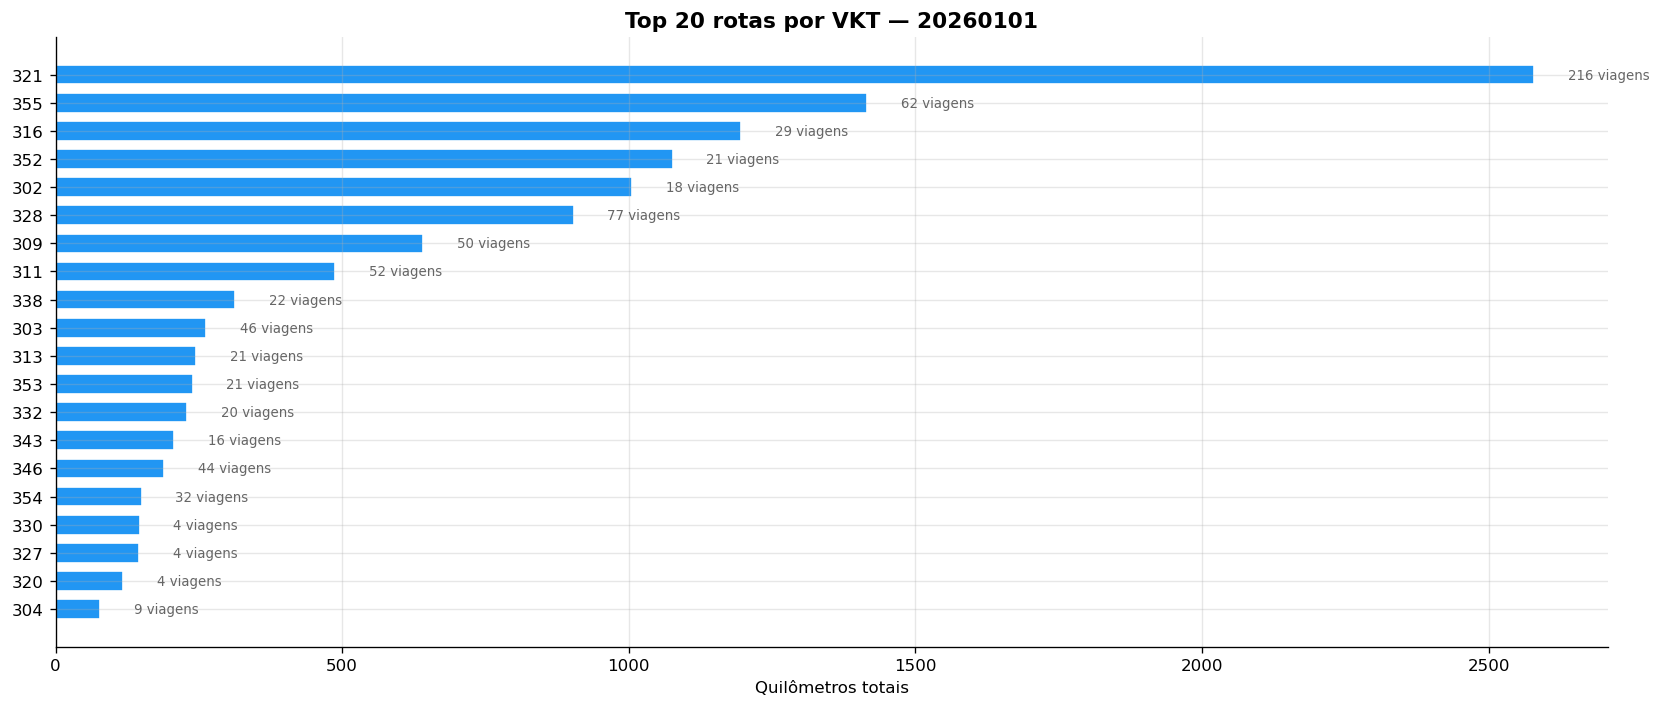

In [46]:
# ── VKT by route (top 20) ───────────────────────────────────────────
route_km = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
    .groupby("route_short_name")
    .agg(
        vkt=("distance_km", "sum"),
        trips=("trip_id", "count"),
        avg_dist=("distance_km", "mean"),
        avg_speed=("speed_kmh", "mean"),
    )
    .sort_values("vkt", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
top20 = route_km.head(20)
bars = ax.barh(
    range(len(top20)), top20["vkt"],
    color=PAL["primary"], edgecolor="white", height=0.7,
)

# Add trip count annotations
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row["vkt"] + total_km * 0.005, i,
            f'{row["trips"]:.0f} viagens', va="center", fontsize=8, color="#666")

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index)
ax.invert_yaxis()
ax.set_xlabel("Quilômetros totais")
ax.set_title(f"Top 20 rotas por VKT — {ANALYSIS_DATE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


faixa_horaria,vkt_km,departures,avg_simultaneous_trips,window_hours,vkt_km_h,departures_h
Madrugada,351.8,16,2.3,5.0,70.4,3.2
Manhã Pico,"2,763.4",186,39.4,4.0,690.8,46.5
Entrepico,"4,319.6",305,41.1,7.0,617.1,43.6
Tarde Pico,"2,844.6",183,46.8,4.0,711.2,45.8
Noite,"1,508.8",91,22.0,4.0,377.2,22.8


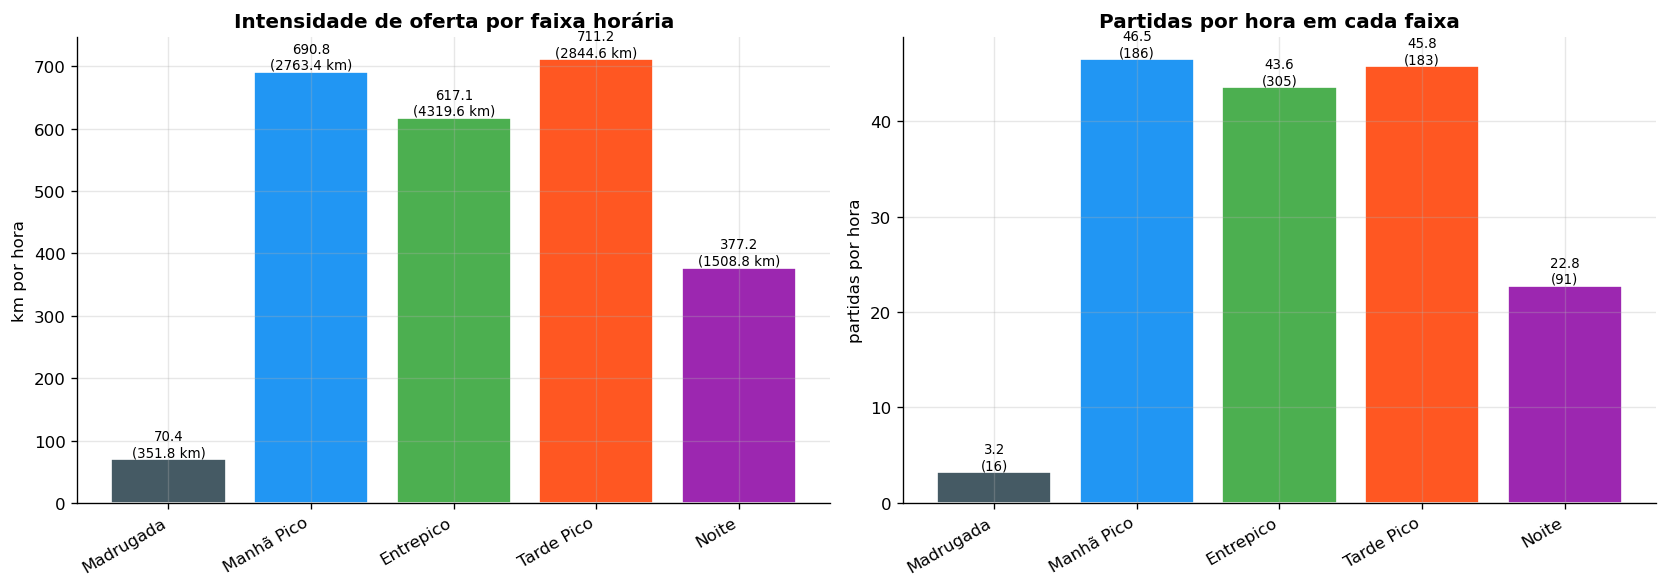

In [47]:
# ── Oferta por faixa horária: totais e intensidades ──────────────────
def hhmmss_to_hours(s):
    hh, mm, ss = map(int, s.split(":"))
    return hh + mm / 60 + ss / 3600

def hour_in_day(h):
    return h % 24

def assign_window(hour):
    h = hour_in_day(hour)
    for name, t0, t1 in TIME_WINDOWS:
        h0 = hhmmss_to_hours(t0)
        h1 = hhmmss_to_hours(t1)
        if h0 <= h < h1:
            return name
    return "Outro"

window_order = [w[0] for w in TIME_WINDOWS]
window_hours = pd.Series(
    {name: hhmmss_to_hours(t1) - hhmmss_to_hours(t0) for name, t0, t1 in TIME_WINDOWS},
    name="window_hours",
)

# Mantém a classificação por faixa no nível da viagem
# útil para a tabela rota × faixa horária
trip_stats["start_hour"] = trip_stats["start_time"].apply(hhmmss_to_hours)
trip_stats["window"] = trip_stats["start_hour"].apply(assign_window)

# Classificação por faixa no nível da série temporal da rede
nts_window = nts.copy()
nts_window["window"] = nts_window["hour"].apply(assign_window)

window_summary = (
    nts_window
    .groupby("window")
    .agg(
        vkt_km=("service_distance", lambda s: s.sum() / 1000),
        departures=("num_trip_starts", "sum"),
        avg_simultaneous_trips=("num_trips", "mean"),
    )
    .reindex(window_order)
    .fillna(0)
)

window_summary = window_summary.join(window_hours)
window_summary["vkt_km_h"] = window_summary["vkt_km"] / window_summary["window_hours"]
window_summary["departures_h"] = window_summary["departures"] / window_summary["window_hours"]

display(
    window_summary
    .reset_index(names="faixa_horaria")
    .style
    .format({
        "vkt_km": "{:,.1f}",
        "departures": "{:,.0f}",
        "avg_simultaneous_trips": "{:.1f}",
        "window_hours": "{:.1f}",
        "vkt_km_h": "{:,.1f}",
        "departures_h": "{:.1f}",
    })
    .set_caption("Oferta por faixa horária — totais e intensidades")
    .hide(axis="index")
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(
    range(len(window_summary)),
    window_summary["vkt_km_h"],
    color=WINDOW_COLORS,
    edgecolor="white",
)
ax1.set_xticks(range(len(window_summary)))
ax1.set_xticklabels(window_summary.index, rotation=30, ha="right")
ax1.set_ylabel("km por hora")
ax1.set_title("Intensidade de oferta por faixa horária", fontweight="bold")

for i, v in enumerate(window_summary["vkt_km_h"]):
    total = window_summary.iloc[i]["vkt_km"]
    ax1.text(i, v, f"{v:.1f}\n({total:.1f} km)", ha="center", va="bottom", fontsize=8)

ax2.bar(
    range(len(window_summary)),
    window_summary["departures_h"],
    color=WINDOW_COLORS,
    edgecolor="white",
)
ax2.set_xticks(range(len(window_summary)))
ax2.set_xticklabels(window_summary.index, rotation=30, ha="right")
ax2.set_ylabel("partidas por hora")
ax2.set_title("Partidas por hora em cada faixa", fontweight="bold")

for i, v in enumerate(window_summary["departures_h"]):
    total = window_summary.iloc[i]["departures"]
    ax2.text(i, v, f"{v:.1f}\n({total:.0f})", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

---
## 6 — Trip Summary Table

Comprehensive overview: trips, distances, and durations broken down by
route, time window, and direction.

In [48]:
# ── Route-level summary ──────────────────────────────────────────────
route_summary = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id", "direction_id"]])
    .merge(feed.routes[["route_id", "route_short_name", "route_long_name"]])
    .groupby(["route_short_name", "route_long_name"])
    .agg(
        viagens=("trip_id", "count"),
        km_total=("distance_km", "sum"),
        km_medio=("distance_km", "mean"),
        duracao_media_min=("duration", lambda x: x.mean() * 60),
        vel_media_kmh=("speed_kmh", "mean"),
    )
    .sort_values("km_total", ascending=False)
    .reset_index()
)

display(
    route_summary
    .head(25)
    .style
    .format({
        "km_total": "{:,.0f}",
        "km_medio": "{:.1f}",
        "duracao_media_min": "{:.0f}",
        "vel_media_kmh": "{:.1f}",
    })
    .background_gradient(subset=["km_total"], cmap="Blues")
    .set_caption(f"Resumo por rota — {ANALYSIS_DATE}")
    .hide(axis="index")
)


route_short_name,route_long_name,viagens,km_total,km_medio,duracao_media_min,vel_media_kmh
321,São Cristóvão / Tangará,216,"2,579",11.9,47,15.8
355,Botafogo / Chavão,62,"1,416",22.8,60,22.9
316,São Cristóvão / Santo Antônio,29,"1,196",41.2,92,27.9
352,São Cristóvão / Santo Antônio,21,"1,077",51.3,106,29.4
302,São Cristóvão / Agrisa,18,"1,005",55.9,113,30.7
328,São Cristóvão / Peró,77,904,11.7,41,17.5
309,São Cristóvão / Parque Eldorado,50,641,12.8,43,18.3
311,Contorno / Vila do Sol,52,487,9.4,32,18.7
338,São Cristóvão / Guriri,22,313,14.2,46,19.3
303,Contorno / Jardim Caiçara,46,262,5.7,27,13.1


In [49]:
# ── Cross-tabulation: trips by route × time window ──────────────────
ts_enriched = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)

cross = (
    ts_enriched
    .groupby(["route_short_name", "window"])["trip_id"]
    .count()
    .unstack(fill_value=0)
)
# Reorder columns
cross = cross.reindex(columns=[w[0] for w in TIME_WINDOWS], fill_value=0)
cross["TOTAL"] = cross.sum(axis=1)
cross = cross.sort_values("TOTAL", ascending=False)

display(
    cross
    .head(20)
    .style
    .background_gradient(cmap="YlOrRd", axis=None,
                          subset=[w[0] for w in TIME_WINDOWS])
    .set_caption("Viagens por rota × faixa horária")
)

window,Madrugada,Manhã Pico,Entrepico,Tarde Pico,Noite,TOTAL
route_short_name,,,,,,
321,6,54,85,47,24,216
328,0,17,34,17,9,77
355,1,13,24,13,11,62
311,0,13,20,13,6,52
309,1,14,18,12,5,50
303,0,10,19,14,3,46
346,0,10,17,9,8,44
354,0,0,15,10,7,32
316,3,8,11,5,2,29


In [50]:
# ── Grand totals ─────────────────────────────────────────────────────
grand = pd.DataFrame({
    "Indicador": [
        "Rotas ativas",
        "Viagens totais",
        "VKT total (km)",
        "Km médio por viagem",
        "Duração média (min)",
        "Velocidade média (km/h)",
        "Horas-veículo totais",
    ],
    "Valor": [
        f"{route_summary['route_short_name'].nunique()}",
        f"{total_trips:,}",
        f"{total_km:,.0f}",
        f"{total_km / max(1, total_trips):.1f}",
        f"{total_duration / max(1, total_trips) * 60:.0f}",
        f"{total_km / max(1e-9, total_duration):.1f}",
        f"{total_duration:,.0f}",
    ],
})

display(
    grand.style
    .set_properties(**{"font-weight": "bold"}, subset=["Indicador"])
    .hide(axis="index")
    .set_caption(f"Totais do dia — {ANALYSIS_DATE}")
)


Indicador,Valor
Rotas ativas,23
Viagens totais,781
VKT total (km),"11,788"
Km médio por viagem,15.1
Duração média (min),47
Velocidade média (km/h),19.4
Horas-veículo totais,607


---
## 7 — Diagnostics

Anomaly detection and quality indicators derived from the GTFS data.

### 7.1 Speed anomalies

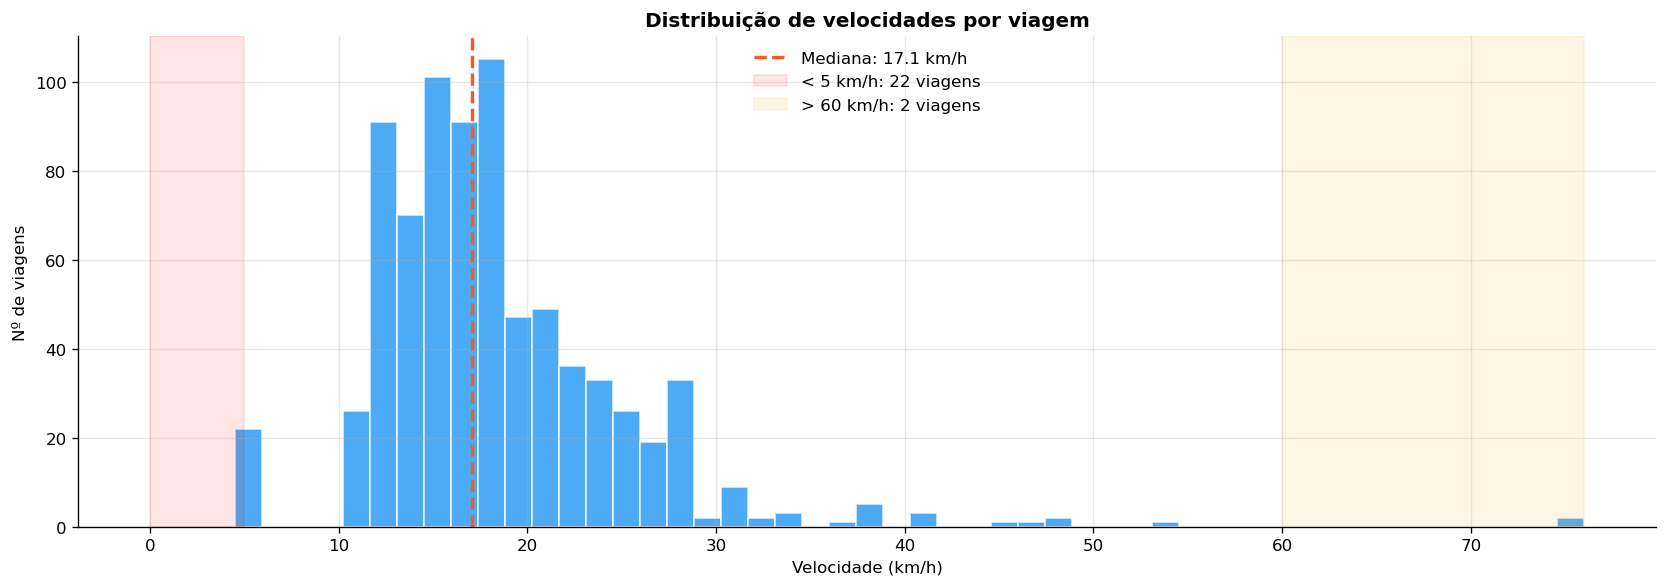


⚠ 22 viagens com velocidade < 5 km/h (possível erro de dados):


,route_short_name,trip_id,distance_km,duration,speed_kmh
619,346,t-r346-sw_05:20:00_05:20:00_DU-05:20:00-1-0,1.9,0.4,4.5
620,346,t-r346-sw_06:10:00_06:10:00_DU-06:10:00-1-0,1.9,0.4,4.5
621,346,t-r346-sw_07:00:00_07:00:00_DU-07:00:00-1-0,1.9,0.4,4.5
622,346,t-r346-sw_07:50:00_07:50:00_DU-07:50:00-1-0,1.9,0.4,4.5
623,346,t-r346-sw_08:40:00_08:40:00_DU-08:40:00-1-0,1.9,0.4,4.5


In [51]:
# ── Speed distribution per route ─────────────────────────────────────
ts_spd = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(ts_spd["speed_kmh"].dropna(), bins=50, color=PAL["primary"],
        edgecolor="white", alpha=0.8)
ax.axvline(ts_spd["speed_kmh"].median(), color=PAL["secondary"], linestyle="--",
           linewidth=2, label=f"Mediana: {ts_spd['speed_kmh'].median():.1f} km/h")

# Flag extremes
slow = ts_spd.loc[ts_spd["speed_kmh"] < 5]
fast = ts_spd.loc[ts_spd["speed_kmh"] > 60]
if not slow.empty:
    ax.axvspan(0, 5, alpha=0.1, color="red", label=f"< 5 km/h: {len(slow)} viagens")
if not fast.empty:
    ax.axvspan(60, ts_spd["speed_kmh"].max(), alpha=0.1, color="orange",
               label=f"> 60 km/h: {len(fast)} viagens")

ax.set_xlabel("Velocidade (km/h)")
ax.set_ylabel("Nº de viagens")
ax.set_title("Distribuição de velocidades por viagem", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

if not slow.empty:
    print(f"\n⚠ {len(slow)} viagens com velocidade < 5 km/h (possível erro de dados):")
    display(
        slow.nsmallest(5, "speed_kmh")
        [["route_short_name", "trip_id", "distance_km", "duration", "speed_kmh"]]
    )


### 7.2 Stop spacing

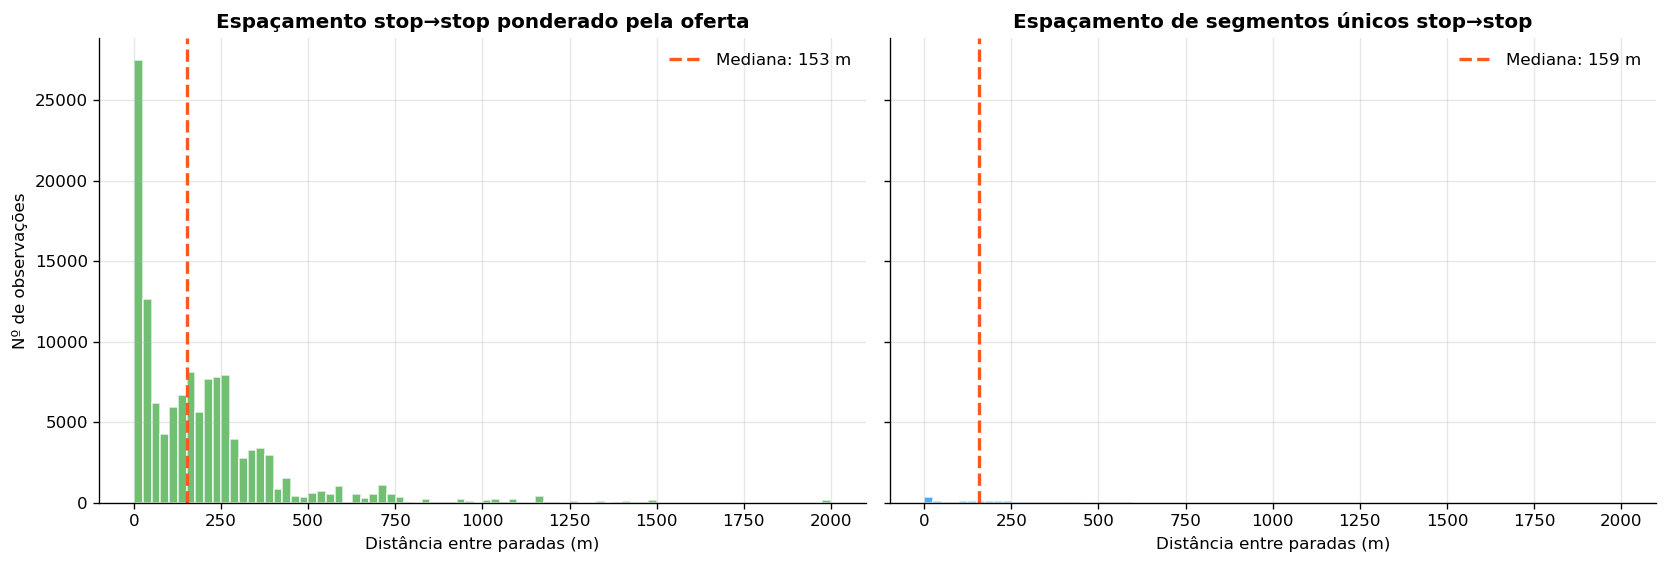

Mediana ponderada pela oferta: 153 m
Mediana de segmentos únicos:   159 m
Oferta > 2 km: 160 (0.1%)
Únicos > 2 km: 8 (0.5%)
Oferta < 100 m: 50196 (39.0%)
Únicos < 100 m: 538 (34.8%)


In [52]:
# ── Inter-stop distance distribution ─────────────────────────────────
st_dist = feed.stop_times.copy()
st_dist = st_dist.sort_values(["trip_id", "stop_sequence"])
st_dist["next_stop_id"] = st_dist.groupby("trip_id")["stop_id"].shift(-1)
st_dist["next_dist"] = st_dist.groupby("trip_id")["shape_dist_traveled"].shift(-1)
st_dist["segment_m"] = st_dist["next_dist"] - st_dist["shape_dist_traveled"]
st_dist = st_dist.dropna(subset=["next_stop_id", "segment_m"]).copy()
st_dist = st_dist.loc[st_dist["segment_m"] > 0].copy()

# 1) Oferta programada: cada passagem do segmento conta novamente
seg_m_weighted = st_dist["segment_m"]

# 2) Segmentos únicos stop->stop: remove a ponderação pela oferta
seg_unique = (
    st_dist
    .groupby(["stop_id", "next_stop_id"], as_index=False)
    .agg(
        segment_m=("segment_m", "median"),
        n_trips=("trip_id", "nunique"),
    )
)
seg_m_unique = seg_unique["segment_m"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

ax1.hist(seg_m_weighted.clip(upper=2000), bins=80, color=PAL["accent"], edgecolor="white", alpha=0.8)
ax1.axvline(seg_m_weighted.median(), color=PAL["secondary"], linestyle="--", linewidth=2,
            label=f"Mediana: {seg_m_weighted.median():.0f} m")
ax1.set_xlabel("Distância entre paradas (m)")
ax1.set_ylabel("Nº de observações")
ax1.set_title("Espaçamento stop→stop ponderado pela oferta", fontweight="bold")
ax1.legend(frameon=False)

ax2.hist(seg_m_unique.clip(upper=2000), bins=80, color=PAL["primary"], edgecolor="white", alpha=0.8)
ax2.axvline(seg_m_unique.median(), color=PAL["secondary"], linestyle="--", linewidth=2,
            label=f"Mediana: {seg_m_unique.median():.0f} m")
ax2.set_xlabel("Distância entre paradas (m)")
ax2.set_title("Espaçamento de segmentos únicos stop→stop", fontweight="bold")
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Mediana ponderada pela oferta: {seg_m_weighted.median():.0f} m")
print(f"Mediana de segmentos únicos:   {seg_m_unique.median():.0f} m")
print(f"Oferta > 2 km: {(seg_m_weighted > 2000).sum()} ({(seg_m_weighted > 2000).mean()*100:.1f}%)")
print(f"Únicos > 2 km: {(seg_m_unique > 2000).sum()} ({(seg_m_unique > 2000).mean()*100:.1f}%)")
print(f"Oferta < 100 m: {(seg_m_weighted < 100).sum()} ({(seg_m_weighted < 100).mean()*100:.1f}%)")
print(f"Únicos < 100 m: {(seg_m_unique < 100).sum()} ({(seg_m_unique < 100).mean()*100:.1f}%)")


### 7.3 Trip duration outliers

In [53]:
# ── Box plot of trip duration by route (top 15 by trip count) ────────
ts_dur = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)
ts_dur["duration_min"] = ts_dur["duration"] * 60

top_routes = ts_dur["route_short_name"].value_counts().head(15).index
ts_dur_top = ts_dur.loc[ts_dur["route_short_name"].isin(top_routes)]

fig = px.box(
    ts_dur_top,
    x="route_short_name", y="duration_min",
    color="route_short_name",
    title="Duração das viagens por rota (top 15)",
    labels={"route_short_name": "Rota", "duration_min": "Duração (min)"},
)
fig.update_layout(showlegend=False, height=500)
fig.show()

### 7.4 Feed completeness

In [54]:
# ── Check for common GTFS issues ────────────────────────────────────
checks = []

# Trips without stop_times
orphan_trips = set(feed.trips["trip_id"]) - set(feed.stop_times["trip_id"])
checks.append(("Viagens sem stop_times", len(orphan_trips),
               "✓" if not orphan_trips else f"⚠ {len(orphan_trips)}"))

# Stops without any visits
visited = set(feed.stop_times["stop_id"])
all_stops = set(feed.stops["stop_id"])
unused = all_stops - visited
checks.append(("Paradas sem visitas", len(unused),
               "✓" if not unused else f"⚠ {len(unused)}"))

# Routes without trips
routes_with_trips = set(feed.trips["route_id"])
all_routes = set(feed.routes["route_id"])
unused_routes = all_routes - routes_with_trips
checks.append(("Rotas sem viagens", len(unused_routes),
               "✓" if not unused_routes else f"⚠ {len(unused_routes)}"))

# Shapes coverage
if feed.shapes is not None:
    shapes_used = set(feed.trips["shape_id"].dropna())
    shapes_defined = set(feed.shapes["shape_id"])
    missing_shapes = shapes_used - shapes_defined
    checks.append(("Shapes faltando", len(missing_shapes),
                   "✓" if not missing_shapes else f"⚠ {len(missing_shapes)}"))

# Null arrival times
null_arr = feed.stop_times["arrival_time"].isna().sum()
checks.append(("stop_times sem arrival_time", null_arr,
               "✓" if null_arr == 0 else f"⚠ {null_arr}"))

# shape_dist_traveled coverage
null_dist = feed.stop_times["shape_dist_traveled"].isna().sum()
pct_null = null_dist / len(feed.stop_times) * 100
checks.append(("shape_dist_traveled nulo", null_dist,
               "✓" if pct_null < 1 else f"⚠ {null_dist} ({pct_null:.1f}%)"))

display(
    pd.DataFrame(checks, columns=["Verificação", "Contagem", "Status"])
    .style
    .applymap(lambda v: "color: green" if v == "✓" else "color: #D32F2F",
              subset=["Status"])
    .hide(axis="index")
    .set_caption("Diagnóstico de completude do feed")
)

Verificação,Contagem,Status
Viagens sem stop_times,0,✓
Paradas sem visitas,0,✓
Rotas sem viagens,0,✓
Shapes faltando,0,✓
stop_times sem arrival_time,0,✓
shape_dist_traveled nulo,0,✓


### 7.5 Route stats table (full)

In [55]:
# ── Full route stats via gtfs_kit ────────────────────────────────────
route_stats = feed.compute_route_stats(
    [ANALYSIS_DATE],
    headway_start_time=HEADWAY_START,
    headway_end_time=HEADWAY_END,
    split_directions=True,
).copy()

# O feed foi lido em metros; converte-se só na apresentação
if "service_distance" in route_stats.columns:
    route_stats["service_distance_km"] = route_stats["service_distance"] / 1000
if "service_speed" in route_stats.columns:
    route_stats["service_speed_kmh"] = route_stats["service_speed"] / 1000

display_cols = [
    c for c in [
        "route_short_name",
        "route_id",
        "direction_id",
        "num_trips",
        "num_trip_starts",
        "mean_headway",
        "max_headway",
        "service_distance_km",
        "service_duration",
        "service_speed_kmh",
    ]
    if c in route_stats.columns
]

fmt = {}
if "max_headway" in display_cols:
    fmt["max_headway"] = "{:.0f}"
if "mean_headway" in display_cols:
    fmt["mean_headway"] = "{:.0f}"
if "service_distance_km" in display_cols:
    fmt["service_distance_km"] = "{:,.1f}"
if "service_duration" in display_cols:
    fmt["service_duration"] = "{:.1f}"
if "service_speed_kmh" in display_cols:
    fmt["service_speed_kmh"] = "{:.1f}"

sort_col = "service_distance_km" if "service_distance_km" in route_stats.columns else display_cols[0]

styled = (
    route_stats[display_cols]
    .sort_values(sort_col, ascending=False)
    .head(30)
    .style
    .format(fmt)
    .set_caption("Estatísticas de rotas por sentido (gtfs_kit)")
    .hide(axis="index")
)

if "service_distance_km" in display_cols:
    styled = styled.background_gradient(subset=["service_distance_km"], cmap="Blues")

display(styled)


route_short_name,route_id,direction_id,num_trips,num_trip_starts,mean_headway,max_headway,service_distance_km,service_duration,service_speed_kmh
321,r321,1,108,108,10,20,"1,430.6",83.7,17.1
321,r321,0,108,108,10,20,"1,148.6",85.5,13.4
355,r355,1,31,31,35,45,801.5,33.3,24.0
316,r316,0,16,16,72,120,652.2,24.8,26.3
352,r352,1,12,12,99,150,620.0,20.7,30.0
355,r355,0,31,31,35,35,614.1,28.7,21.4
316,r316,1,13,13,76,120,544.0,19.8,27.5
302,r302,1,9,9,135,140,510.7,15.9,32.2
302,r302,0,9,9,133,150,494.8,18.0,27.5
328,r328,1,40,40,26,40,486.7,27.3,17.8


---

### Notas metodológicas

- **Data de análise**: dia definido no contexto do estudo.
- **Headways em parada**: calculados entre 06:00–22:00, agregando sentidos na mesma parada.
- **Estatísticas por rota**: calculadas por sentido (`split_directions=True`) para evitar headways artificialmente baixos ao colapsar ida e volta.
- **Distâncias e velocidades**: o feed é lido em metros; tabelas e gráficos convertem para km e km/h apenas na apresentação.
- **Corredores**: o mapa de concentração agrega ida e volta no mesmo corredor, a partir de pares não ordenados de paradas consecutivas.
- **Espaçamento entre paradas**: mostrado em duas leituras — ponderado pela oferta programada e por segmentos únicos stop→stop.
- **Ferramentas**: `gtfs_kit` (análise), `plotly` (mapas), `matplotlib` (gráficos).
